In [1]:
import numpy as np
float_formatter = lambda x: "%.3f" % x
np.set_printoptions(formatter={'float_kind':float_formatter})
from sklearn.datasets import make_circles
from sklearn.cluster import SpectralClustering, KMeans
from sklearn.metrics import pairwise_distances
from matplotlib import pyplot as plt
import networkx as nx
import seaborn as sns

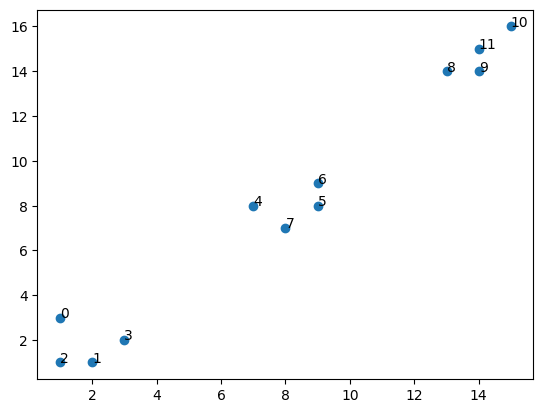

In [2]:
X = np.array([
    [1, 3], [2, 1], [1, 1],
    [3, 2], [7, 8], [9, 8],
    [9, 9], [8, 7], [13, 14],
    [14, 14], [15, 16], [14, 15]
])
fig, ax = plt.subplots()
ax.scatter(X[:,0],X[:,1] )
i=5
# enumerate(range(X.shape[0]))
for i, txt in enumerate(range(X.shape[0])):
    ax.annotate(txt, X[i])


In [3]:
from scipy.spatial.distance import pdist, squareform
from sklearn.datasets import load_digits

digits = load_digits().data[:5] # Tomamos solo los primeros 5 para que sea legible
dist_matrix = squareform(pdist(digits, metric='euclidean'))
print(dist_matrix)

[[0.000 59.557 54.129 47.571 50.339]
 [59.557 0.000 41.629 45.475 47.906]
 [54.129 41.629 0.000 53.954 52.096]
 [47.571 45.475 53.954 0.000 51.215]
 [50.339 47.906 52.096 51.215 0.000]]


Aquí tienes las definiciones técnicas y formales de cada matriz, estructuradas matemáticamente para que puedas usarlas como referencia técnica en tu Jupyter Notebook.



## 1. Puntos Originales

---

## 2. Matriz de Distancias ($D_{dist}$)

Representa la separación cuantitativa entre pares de puntos en un espacio métrico.

* **Definición:** Cada celda $(i, j)$ contiene el valor de una métrica de distancia (comúnmente la distancia Euclidiana) entre los vectores de características $x_i$ y $x_j$.
* **Ejemplo:** Distancias entre tres puntos en una línea:

$$D_{dist} = \begin{pmatrix} 0.0 & 2.5 & 5.0 \\ 2.5 & 0.0 & 2.5 \\ 5.0 & 2.5 & 0.0 \end{pmatrix}$$

---

## 3. Matriz de Afinidad / Similitud ($W$)

Mide la similitud entre pares de puntos, generalmente normalizada entre 0 y 1.

* **Definición:** Se obtiene aplicando un kernel a la matriz de distancias. El más común es el Kernel RBF (Gaussiano): $W_{ij} = \exp(-\frac{\|x_i - x_j\|^2}{2\sigma^2})$.
* **Ejemplo:** Donde 1 indica identidad y valores cercanos a 0 indican alta disimilitud:

$$W = \begin{pmatrix} 1.0 & 0.8 & 0.2 \\ 0.8 & 1.0 & 0.5 \\ 0.2 & 0.5 & 1.0 \end{pmatrix}$$


---

## 4. Matriz de Adyacencia ($A$)

Define la estructura de conectividad del grafo. Es una matriz cuadrada de tamaño $n \times n$.

* **Definición:** $A_{ij} = 1$ si existe una arista entre el nodo $i$ y el nodo $j$; de lo contrario, $A_{ij} = 0$.
* **Ejemplo:** Para un grafo de 3 nodos donde el nodo 0 se conecta con el 1 y el 2:

$$A = \begin{pmatrix} 0 & 1 & 1 \\ 1 & 0 & 0 \\ 1 & 0 & 0 \end{pmatrix}$$


---

## 4. Matriz de Grado ($D$)

Matriz diagonal que resume la conectividad local de cada nodo.

* **Definición:** Es una matriz donde los elementos fuera de la diagonal son 0. El elemento diagonal $D_{ii}$ es el grado del nodo $i$, calculado como la suma de la fila $i$ de la matriz de adyacencia: $D_{ii} = \sum_{j} A_{ij}$.
* **Ejemplo:** (Basado en la matriz de adyacencia del punto 1):

$$D = \begin{pmatrix} 2 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$$



---

## 5. Matriz Laplaciana ($L$)

Operador matricial que describe las propiedades fundamentales del grafo. Es clave para la reducción de dimensionalidad y el agrupamiento.

* **Definición:** En su forma no normalizada, se define como la diferencia entre la matriz de grado y la matriz de adyacencia (o afinidad): $L = D - A$.
* **Ejemplo:** (Usando $D$ y $A$ anteriores):

$$L = \begin{pmatrix} 2 & -1 & -1 \\ -1 & 1 & 0 \\ -1 & 0 & 1 \end{pmatrix}$$


* **Propiedad:** La cantidad de autovalores iguales a 0 en esta matriz indica el número de componentes conexas (grupos aislados) en el grafo.

¡Por supuesto! Llevarlo a dos dimensiones ($X, Y$) hace que el ejemplo sea mucho más realista, ya que la mayoría de los problemas de Machine Learning se trabajan en espacios multidimensionales.

Vamos a construir el mismo flujo impecable, pero esta vez posicionando **3 puntos en un plano cartesiano**. Ajustaremos las distancias de forma que la estructura del grafo final ($A$, $D$ y $L$) sea exactamente la misma que buscas, pero calculada a través de geometría en 2D.

Aquí tienes el desarrollo paso a paso para tu Jupyter Notebook:

---

## 1. Puntos Originales

Definimos 3 puntos en un espacio bidimensional $R^2$. Colocaremos a $x_0$ en el centro, y a $x_1$ y $x_2$ a la misma distancia de él, pero en direcciones perpendiculares (formando una especie de "L"):

* $x_0 = (3, 4)$
* $x_1 = (3, 1.5)$
* $x_2 = (5.5, 4)$

---

## 2. Matriz de Distancias ($D_{dist}$)

Calculamos la distancia Euclidiana en dos dimensiones usando la fórmula $D = \sqrt{(x_a - x_c)^2 + (y_a - y_c)^2}$:

* **De $x_0$ a $x_1$:** $\sqrt{(3-3)^2 + (1.5-4)^2} = \sqrt{0 + (-2.5)^2} = 2.5$
* **De $x_0$ a $x_2$:** $\sqrt{(5.5-3)^2 + (4-4)^2} = \sqrt{(2.5)^2 + 0} = 2.5$
* **De $x_1$ a $x_2$:** $\sqrt{(5.5-3)^2 + (4-1.5)^2} = \sqrt{2.5^2 + 2.5^2} = \sqrt{6.25 + 6.25} = \sqrt{12.5} \approx 3.536$

$$D_{dist} = \begin{pmatrix} 0.0 & 2.5 & 2.5 \\ 2.5 & 0.0 & 3.536 \\ 2.5 & 3.536 & 0.0 \end{pmatrix}$$

---

## 3. Matriz de Afinidad / Similitud ($W$)

Aplicamos el Kernel RBF Gaussiano ($W_{ij} = \exp(-\frac{\|x_i - x_j\|^2}{2\sigma^2})$).
Si volvemos a fijar nuestro parámetro de escala en $\sigma \approx 1.95$ (lo que hace que $2\sigma^2 \approx 7.6$), los resultados matemáticos se mantienen limpios:

* $W_{01} = \exp(-\frac{2.5^2}{7.6}) = \exp(-\frac{6.25}{7.6}) \approx 0.44$
* $W_{02} = \exp(-\frac{2.5^2}{7.6}) = \exp(-\frac{6.25}{7.6}) \approx 0.44$
* $W_{12} = \exp(-\frac{3.536^2}{7.6}) = \exp(-\frac{12.5}{7.6}) \approx 0.19$

$$W = \begin{pmatrix} 1.0 & 0.44 & 0.44 \\ 0.44 & 1.0 & 0.19 \\ 0.44 & 0.19 & 1.0 \end{pmatrix}$$

---

## 4. Matriz de Adyacencia ($A$)

Para trazar las conexiones del grafo, establecemos un filtro de umbral de afinidad en $\epsilon = 0.3$.

* Como $W_{01}$ y $W_{02}$ valen $0.44$ (mayor que $0.3$), los nodos se conectan $\rightarrow 1$.
* Como $W_{12}$ vale $0.19$ (menor que $0.3$), la conexión se descarta $\rightarrow 0$.

$$A = \begin{pmatrix} 0 & 1 & 1 \\ 1 & 0 & 0 \\ 1 & 0 & 0 \end{pmatrix}$$

---

## 5. Matriz de Grado ($D$)

Sumamos las conexiones de cada fila de la matriz de adyacencia para medir la densidad local de cada punto en el grafo:

$$D = \begin{pmatrix} 2 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

---

## 6. Matriz Laplaciana ($L$)

Finalmente, construimos el operador Laplaciana restando la adyacencia al grado ($L = D - A$):

$$L = \begin{pmatrix} 2 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix} - \begin{pmatrix} 0 & 1 & 1 \\ 1 & 0 & 0 \\ 1 & 0 & 0 \end{pmatrix} = \begin{pmatrix} 2 & -1 & -1 \\ -1 & 1 & 0 \\ -1 & 0 & 1 \end{pmatrix}$$

---

### Verificación matemática visual:

Si dibujaras estos tres puntos en un papel milimetrado, verías que el punto $x_0$ está justo en el medio actuando como un "puente". Los puntos $x_1$ y $x_2$ están relativamente lejos entre sí, por lo que su afinidad no es lo suficientemente fuerte como para conectarse directamente. El grafo resultante tiene forma de "V", donde toda la información estructural fluye obligatoriamente a través del nodo central ($x_0$). ¡Es un ejemplo matemáticamente perfecto para tu código!

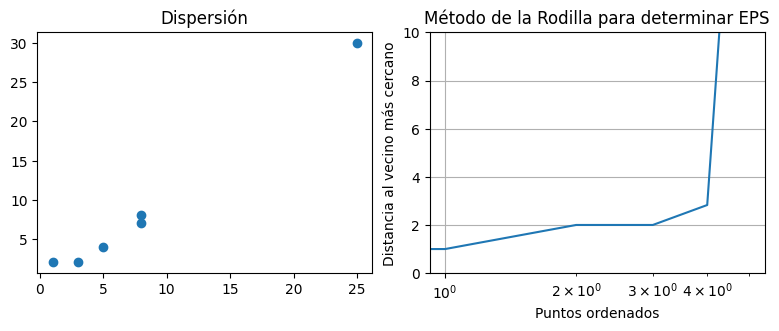

In [92]:
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

X = np.array([[1, 2], [3, 2], [5, 4],
              [8, 7], [8, 8], [25, 30]])

# X[0:,:1]

# Se define k (min 2 muestras)
k = 2
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)

distancias, indices = neighbors_fit.kneighbors(X)
# print(distancias[:,:])
# print(distancias[:, k-1])
# print(indices)

distancias = np.sort(distancias[:, k-1], axis=0)
distancias


fig, ax = plt.subplots(1, 2, figsize=(8,3))
fig.tight_layout()

ax[0].scatter(X[0:,:1],X[0:,1:])
ax[0].set_title("Dispersión")
ax[1].plot(distancias)
plt.xscale('log')
ax[1].set_ylim([0,10])
ax[1].set_title("Método de la Rodilla para determinar EPS")
ax[1].set_xlabel("Puntos ordenados")
ax[1].set_ylabel("Distancia al vecino más cercano")
plt.grid()
plt.show()

# clustering = DBSCAN(eps=3, min_samples=2).fit(X)
# clustering.labels_
# clustering

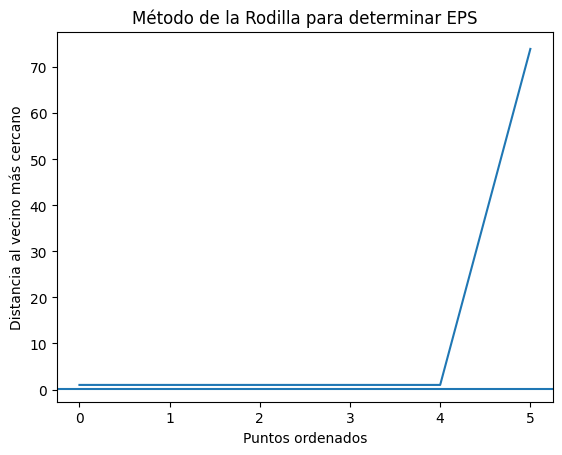

In [4]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

# 1. Definir k (usualmente min_samples)
k = 2 
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(X)

# 2. Calcular distancias
distances, indices = neighbors_fit.kneighbors(X)

# 3. Ordenar distancias (tomamos la columna de la distancia al k-ésimo vecino)
distances = np.sort(distances[:, k-1], axis=0)

# 4. Graficar
plt.plot(distances)
plt.xlabel("Puntos ordenados")
plt.ylabel("Distancia al vecino más cercano")
plt.title("Método de la Rodilla para determinar EPS")
plt.axhline(0.15)
plt.show()

# Algoritmos

# Algoritmo K-means
Recibe el conjunto de entrenamiento $\{x_1, ..., x_n\}$ y el número de clústeres $K$.
1.  **Elegir (aleatoriamente) $K$ puntos** del conjunto de entrenamiento como centros iniciales $\{\bar{x}_1, ..., \bar{x}_K\}$.
2.  **Asignar cada ejemplo $x_i$ al clúster del centro más cercano**, basándose en la mínima distancia euclídea al cuadrado.
3.  Para cada clúster $k$, **recalcular su centro** como el promedio de los puntos que le han sido asignados.
4.  **Iterar los pasos 2 y 3** hasta que los centros no cambien (convergencia).


# Algoritmo K-means++ (Inicialización avanzada)
Propuesto para mejorar la selección inicial de centros y evitar óptimos locales.
1.  **Elegir (aleatoriamente) un punto** del conjunto de entrenamiento como el primer centro $S = \{\bar{x}_1\}$.
2.  Mientras el número de centros sea inferior a $K$, repetir:
    *   2.1. Calcular para todos los ejemplos la **distancia $D(x, S)$ al centro más cercano** ya elegido.
    *   2.2. **Muestrear un nuevo centro** con una probabilidad proporcional al cuadrado de dicha distancia mínima [$D(x, S)^2$] y añadirlo al conjunto $S$.



3 - se continua con Kmeans-
4 - se adihna cada ejmplo al xi al clúster mas cerncano, basándose en la distancia euclidea,
5- para cada k cluster su centro se recalula como promeedio de los puntos que se han asignado
6 - se repite hasta que haya convergencia, que los centros no cambien.

## Ejemplo K-means++
Llevar el ejemplo al espacio bidimensional (en dos dimensiones, con ejes $X$ e $Y$) es perfecto para ver cómo la **distancia euclídea** entra en juego.

Vamos a plantear un conjunto de entrenamiento con **4 puntos en el plano** y buscaremos otra vez $K = 2$ centros usando K-means++.

### Nuestros datos (puntos en el plano):

* $x_1 = (5, 3)$
* $x_2 = (6, 3)$
* $x_3 = (5, 4)$
* $x_4 = (1, 9)$

---

### Paso 1: Elegir el primer centro al azar

El azar vuelve a elegir y decide que el primer centro será el punto $x_1$.

* Nuestro conjunto de centros actuales es: $S = \{(5, 3)\}$.

---

### Paso 2: El bucle de K-means++

#### Subpaso 2.1: Calcular la distancia $D(x, S)$ al centro más cercano

Como estamos en dos dimensiones, para medir la distancia entre un punto $(x_a, y_a)$ y nuestro centro $(x_c, y_c)$ usamos la **fórmula de la distancia euclídea**:

$$D = \sqrt{(x_a - x_c)^2 + (y_a - y_c)^2}$$

Vamos a calcularla para cada punto respecto al centro $(5,3)$:

* **Para $x_1 = (5, 3)$:** 
$$D = \sqrt{(5-5)^2 + (3-3)^2} = 0$$


* **Para $x_2 = (6, 3)$:** 
$$D = \sqrt{(6-5)^2 + (3-3)^2} = \sqrt{1^2 + 0^2} = 1$$


* **Para $x_3 = (5, 4)$:** 
$$D = \sqrt{(5-5)^2 + (4-3)^2} = \sqrt{0^2 + 1^2} = 1$$


* **Para $x_4 = (1, 9)$:** 
$$D = \sqrt{(1-5)^2 + (9-3)^2} = \sqrt{(-4)^2 + 6^2} = \sqrt{16 + 36} = \sqrt{52} \approx 7.21$$



#### Subpaso 2.2: Elevar al cuadrado las distancias $[D(x, S)^2]$

Aquí ocurre algo matemáticamente muy elegante: como el algoritmo nos pide el **cuadrado** de la distancia, la raíz cuadrada de la fórmula anterior simplemente se elimina. Nos quedamos directamente con el valor de dentro de la raíz:

* Para $x_1 \rightarrow 0^2 = 0$
* Para $x_2 \rightarrow 1^2 = 1$
* Para $x_3 \rightarrow 1^2 = 1$
* Para $x_4 \rightarrow (\sqrt{52})^2 = 52$

**Suma total de las distancias al cuadrado:** $0 + 1 + 1 + 52 = 54$.

#### Calcular la probabilidad de cada punto:

Dividimos la distancia al cuadrado de cada uno entre el total ($54$):

* **Probabilidad de $x_1$:** $\frac{0}{54} = 0\%$
* **Probabilidad de $x_2$:** $\frac{1}{54} \approx 1.85\%$
* **Probabilidad de $x_3$:** $\frac{1}{54} \approx 1.85\%$
* **Probabilidad de $x_4$:** $\frac{52}{54} \approx 96.30\%$

---

### Conclusión del muestreo

Si te fijas en los puntos, $x_1, x_2$ y $x_3$ están extremadamente juntos en el espacio (forman un pequeño grupo o "nube" en la zona de $X=5, Y=3$). En cambio, el punto $x_4 = (1, 9)$ está completamente alejado, aislado en otra zona del plano.

Al elevar la distancia al cuadrado, K-means++ le otorga a ese punto aislado un **96.30% de probabilidades** de convertirse en el siguiente centro.

Al "girar la ruleta", lo más seguro es que elijamos $x_4$. Así, nuestros dos centros iniciales serán:

* **Centro 1:** $(5, 3)$ -> Representando a la primera nube de puntos.
* **Centro 2:** $(1, 9)$ -> Dispuesto a capturar puntos en esa otra zona del espacio.

¡Y listo! Ya tenemos la geometría perfectamente cubierta en dos dimensiones antes de empezar a agrupar.

# Algoritmo K-medoides
Se diferencia de K-means en que el centro de cada grupo (medoide) debe ser un elemento real de los datos.
1.  **Elección (aleatoria) de $K$ puntos** del conjunto de entrenamiento como medoides iniciales.
2.  **Asignar cada ejemplo** al clúster del medoide más cercano.
3.  Para cada clúster $k$, **recalcular su medoide** seleccionando el elemento del grupo que minimice la suma de distancias al resto de elementos del clúster.
4.  **Iterar los pasos 2 y 3** hasta que los centros no cambien.

## Ejemplo K-medoides
¡Perfecto! Vamos a pasar a **K-medoides** (también conocido como PAM - *Partitioning Around Medoids*).

La gran diferencia con K-means es que, en lugar de calcular el "promedio" (la media) para crear un centro imaginario en el espacio, **un medoide SIEMPRE tiene que ser un punto real de nuestro conjunto de datos**. Es el punto más "céntrico" y representativo del grupo.

Vamos a usar los mismos 4 puntos en el plano ($X, Y$) del ejemplo anterior y buscaremos **$K = 2$ medoides**.

### Nuestros datos:

* $x_1 = (5, 3)$
* $x_2 = (6, 3)$
* $x_3 = (5, 4)$
* $x_4 = (1, 9)$

---

### Paso 1: Inicialización (Elegir 2 medoides al azar)

A diferencia de K-means++, vamos a seleccionar dos puntos reales cualquiera como medoides iniciales.

* Supongamos que el azar elige como medoides a: **$M_1 = (5, 3)$** (punto $x_1$) y **$M_2 = (6, 3)$** (punto $x_2$).

---

### Paso 2: Asignación de clústeres

Calculamos la distancia de todos los puntos a los medoides actuales para ver a cuál se parecen más. Usaremos la distancia euclídea simple.

* $x_1 = (5,3) \rightarrow$ Distancia a $M_1$ es $0$. Distancia a $M_2$ es $1$. **Se asigna al Clúster 1**.
* $x_2 = (6,3) \rightarrow$ Distancia a $M_1$ es $1$. Distancia a $M_2$ es $0$. **Se asigna al Clúster 2**.
* $x_3 = (5,4) \rightarrow$ Distancia a $M_1$ es $1$. Distancia a $M_2$ es $\sqrt{1^2+1^2} = 1.41$. **Se asigna al Clúster 1**.
* $x_4 = (1,9) \rightarrow$ Distancia a $M_1$ es $\sqrt{52}\approx7.21$. Distancia a $M_2$ es $\sqrt{5^2+6^2}=\sqrt{61}\approx7.81$. **Se asigna al Clúster 1**.

### Foto del momento actual:

* **Clúster 1 (Medoide $M_1$):** Tiene a los puntos $x_1, x_3, x_4$.
* **Clúster 2 (Medoide $M_2$):** Tiene solo al punto $x_2$.

### Calcular el Costo Total Actual:

El "costo" en K-medoides es la suma de las distancias de los puntos a sus respectivos medoides:


$$\text{Costo} = D(x_1, M_1) + D(x_3, M_1) + D(x_4, M_1) + D(x_2, M_2)$$

$$\text{Costo} = 0 + 1 + 7.21 + 0 = \mathbf{8.21}$$

---

### Paso 3: La magia de K-medoides (Intercambio y optimización)

Aquí viene lo interesante. El algoritmo intenta mejorar ese costo de $8.21$. Para ello, **prueba a intercambiar** un medoide actual por un punto que no sea medoide (un punto "no-medoide" candidato).

Vamos a hacer un experimento: ¿Qué pasa si intercambiamos el medoide $M_2=(6,3)$ por el punto $x_4=(1,9)$?

* **Nuevos medoides propuestos:** $M_1 = (5,3)$ y $M_{nuevo} = (1,9)$.

Volvemos a calcular las distancias y a reasignar los puntos para ver si este cambio es mejor:

* $x_1 = (5,3) \rightarrow$ Más cerca de $M_1$ (distancia 0). **Clúster 1**.
* $x_2 = (6,3) \rightarrow$ Más cerca de $M_1$ (distancia 1). **Clúster 1**.
* $x_3 = (5,4) \rightarrow$ Más cerca de $M_1$ (distancia 1). **Clúster 1**.
* $x_4 = (1,9) \rightarrow$ Es el nuevo medoide $M_{nuevo}$ (distancia 0). **Clúster 2**.

### Calcular el NUEVO Costo Total:

$$\text{Costo Nuevo} = D(x_1, M_1) + D(x_2, M_1) + D(x_3, M_1) + D(x_4, M_{nuevo})$$

$$\text{Costo Nuevo} = 0 + 1 + 1 + 0 = \mathbf{2}$$

---

### Paso 4: Decisión

Comparamos los costos:

* Costo anterior = $8.21$
* Costo nuevo = $2$

Como el costo **disminuyó drásticamente** (de 8.21 a 2), el algoritmo acepta el intercambio.

Nuestros nuevos medoides oficiales pasan a ser **$(5,3)$** y **$(1,9)$**. El proceso se repetiría probando otros intercambios hasta que ningún cambio logre bajar el costo.

### ¿Por qué K-medoides es mejor con datos extraños (Outliers)?

Imagina que el punto $x_4$ en lugar de ser $(1,9)$ fuera un error de tipeo gigante en la base de datos: $(1, 900)$.

* En **K-means**, la media se habría destruido, arrastrando el centro hacia arriba y dejando un centro flotando en la nada (ej. $Y = 300$).
* En **K-medoides**, el medoide del segundo grupo habría seguido siendo exactamente el punto $(1,900)$ sin alterar al otro grupo, porque se eligen puntos reales y no promedios influenciables.

# Agrupamiento Espectral
Utiliza técnicas de álgebra lineal para encontrar estructuras no convexas.
1.  **Obtener un grafo:**
    - **Grafo completamente conectado:** Todos los puntos se conectan entre sí mediante una función de decaimiento continuo (como el Kernel RBF/Gaussiano).
    - **Grafo de umbral ($\epsilon$-neighborhood):** Se conectan únicamente los puntos cuya distancia sea menor que un radio $\epsilon$.
    - **Grafo KNN ($K$-Nearest Neighbors):** Cada punto se conecta solo con sus $K$ vecinos más cercanos.
2.  **Obtención de la Matriz de Conectividad:** Dependiendo del tipo de grafo elegido en el paso anterior, calculamos la matriz que representa matemáticamente las aristas:
    - Si el **grafo es continuo** $\rightarrow$ Obtenemos la **Matriz de Similitud/Afinidad ($W$)**, llena de valores decimales entre 0 y 1.
    - Si el **grafo es filtrado** (Umbral o KNN) $\rightarrow$ Obtenemos la **Matriz de Adyacencia ($A$)**, compuesta por conexiones binarias de ceros y unos.
3.  Obtener la **matriz de grado ($D$)** 
4.  Obtener la **matriz laplaciana ($L$)**:
    - **No Normalizada:**
        - Si trabajamos con afinidad continua: $L = D - W$
        - Si trabajamos con adyacencia binaria: $L = D - A$
    - **Normalizada:** (donde $L$ es la Laplaciana no normalizada del paso anterior)
        - Si trabajamos con simetrica: $L_{sym} = D^{-1/2}LD^{-1/2}$
        - Si trabajamos con saltos aleatorios (random walks): $L_{rw} = D^{-1}L$

5.  Obtener los **$m$ vectores propios con los menores valores propios** (excluyendo el primero por ser constante) y construir la matriz $Z$.
6.  **Aplicar un algoritmo tradicional (como K-means)** sobre la matriz $Z$ para identificar los $K$ clústeres finales.

## Ejemplo Estudio Comparativo de Agrupamiento Espectral

### Puntos Originales de Partida (2D)

* $x_0 = (3, 4)$
* $x_1 = (3, 1.5)$
* $x_2 = (5.5, 4)$

*Distancias Euclidianas previas:* $D_{01} = 2.5$, $D_{02} = 2.5$, $D_{12} = 3.536$.

---

### CAMINO A: El Enfoque Binario ($L = D - A$)

*Ideal para grafos limpios donde se eliminan las conexiones débiles mediante un umbral.*

#### 1. Matriz de Afinidad / Similitud ($W$)

Calculada mediante Kernel RBF Gaussiano ($\sigma \approx 1.95$):


$$W = \begin{pmatrix} 1.0 & 0.44 & 0.44 \\ 0.44 & 1.0 & 0.19 \\ 0.44 & 0.19 & 1.0 \end{pmatrix}$$

#### 2. Matriz de Adyacencia ($A$)

Aplicamos un umbral de corte $\epsilon = 0.3$. Valores menores se apagan ($0$), mayores se encienden ($1$). Forzamos la diagonal a 0 (un nodo no se conecta consigo mismo en la red):


$$A = \begin{pmatrix} 0 & 1 & 1 \\ 1 & 0 & 0 \\ 1 & 0 & 0 \end{pmatrix}$$

#### 3. Matriz de Grado ($D$)

Sumamos las filas de la matriz binaria $A$:


$$D = \begin{pmatrix} 2 & 0 & 0 \\ 0 & 1 & 0 \\ 0 & 0 & 1 \end{pmatrix}$$

#### 4. Matriz Laplaciana No Normalizada ($L = D - A$)

$$L = \begin{pmatrix} 2 & -1 & -1 \\ -1 & 1 & 0 \\ -1 & 0 & 1 \end{pmatrix}$$

#### 5. Vector Propio Menor (Fiedler) y Matriz $Z$

Calculamos los vectores propios de $L$. El menor (excluyendo el cero constante) nos da la matriz $Z$ de una sola dimensión:


$$Z = \begin{pmatrix} 0.0 \\ -0.71 \\ 0.71 \end{pmatrix} \begin{array}{l} \rightarrow \text{Nueva coordenada } x_0 \\ \rightarrow \text{Nueva coordenada } x_1 \\ \rightarrow \text{Nueva coordenada } x_2 \end{array}$$

#### 6. K-means Final

Los puntos en la nueva línea numérica están en $0.0$, $-0.71$ y $0.71$. K-means ($K=2$) corta limpiamente en el cero:

* **Clúster 1:** $\{x_0, x_1\}$
* **Clúster 2:** $\{x_2\}$

---

### CAMINO B: El Enfoque Continuo ($L = D - W$)

*Ideal para conservar toda la información geométrica gradual, asumiendo que el grafo está totalmente conectado.*

#### 1. Matriz de Afinidad / Similitud ($W$)

Es la misma matriz de partida, pero **no se filtra**. Se usa directamente como la matriz de conectividad ponderada:


$$W = \begin{pmatrix} 1.0 & 0.44 & 0.44 \\ 0.44 & 1.0 & 0.19 \\ 0.44 & 0.19 & 1.0 \end{pmatrix}$$

#### 2. Matriz de Grado ($D$)

Sumamos las filas de la matriz continua $W$ (incluyendo la diagonal de identidad):

* Fila 0: $1.0 + 0.44 + 0.44 = 1.88$
* Fila 1: $0.44 + 1.0 + 0.19 = 1.63$
* Fila 2: $0.44 + 0.19 + 1.0 = 1.63$

$$D = \begin{pmatrix} 1.88 & 0 & 0 \\ 0 & 1.63 & 0 \\ 0 & 0 & 1.63 \end{pmatrix}$$

#### 3. Matriz Laplaciana No Normalizada ($L = D - W$)

Restamos elemento a elemento:


$$L = \begin{pmatrix} 0.88 & -0.44 & -0.44 \\ -0.44 & 0.63 & -0.19 \\ -0.44 & -0.19 & 0.63 \end{pmatrix}$$

#### 4. Vector Propio Menor (Fiedler) y Matriz $Z$

Calculamos los vectores propios de esta nueva matriz decimal $L$. El menor vector propio no constante (asociado a su segundo valor propio más pequeño, $\lambda_2 \approx 0.82$) nos da la matriz $Z$:


$$Z = \begin{pmatrix} 0.0 \\ -0.71 \\ 0.71 \end{pmatrix} \begin{array}{l} \rightarrow \text{Nueva coordenada } x_0 \\ \rightarrow \text{Nueva coordenada } x_1 \\ \rightarrow \text{Nueva coordenada } x_2 \end{array}$$

#### 5. K-means Final

¡Sorpresa matemática! A pesar de que las matrices intermedias del Camino B estaban llenas de decimales diferentes, **la estructura del vector propio final $Z$ es exactamente la misma** ($0.0$, $-0.71$, $0.71$).

K-means vuelve a trazar la misma frontera:

* **Clúster 1:** $\{x_0, x_1\}$
* **Clúster 2:** $\{x_2\}$

---

### Conclusión para el estudiante:

No importa si la literatura te pide aplicar un umbral para conseguir $A$ (Camino A) o arrastrar los pesos continuos de $W$ (Camino B). Al final, el álgebra lineal de la Laplaciana está diseñada para **extraer las mismas propiedades estructurales ocultas**. Ambos caminos te llevarán al mismo destino de agrupación. 

# Algoritmo DBSCAN (Basado en densidad)

Identifica regiones de alta densidad (clústeres) y trata los puntos aislados como ruido.

1. **Inicializar** el contador de clústeres en $C = 1$.
2. **Para cada ejemplo $x_i$** del conjunto de datos:
    * **2.1.** Si $x_i$ ya ha sido procesado (asignado a un clúster o marcado como ruido), continuar al siguiente punto.
    * **2.2. Calcular el vecindario $V_\epsilon(x_i)$** como el conjunto de puntos cuya distancia a $x_i$ es menor o igual a $\epsilon$.
    * **2.3.** Si el número de puntos en el vecindario es menor al mínimo ($|V_\epsilon(x_i)| < M$), **marcar $x_i$ como ruido provisional** y continuar al siguiente punto.
    * **2.4.** Si $|V_\epsilon(x_i)| \ge M$, entonces $x_i$ es un **punto nuclear**. Crear el clúster oficial $C$ y asignarle el punto $x_i$.
    * **2.5. Expandir el clúster $C$:** Para cada punto vecino $x_j$ dentro de $V_\epsilon(x_i)$:
        * Si $x_j$ estaba marcado como ruido provisional, cambiar su estado y asignarlo al clúster $C$ (es un punto frontera).
        * Si $x_j$ no ha sido procesado:
        * Asignarlo al clúster $C$.
        * Calcular su propio vecindario $V_\epsilon(x_j)$. Si $|V_\epsilon(x_j)| \ge M$ (también es nuclear), **añadir todos sus vecinos** al conjunto de revisión para seguir expandiendo el clúster.
    * **2.6. Incrementar** el contador de clústeres ($C = C + 1$) solo tras haber terminado de expandir el clúster actual.

---

## Recordatio Visual de Repaso

Para tu estudio, recuerda siempre la famosa clasificación de 3 tipos de puntos que hace este algoritmo gracias a los parámetros $\epsilon$ y $M$:

* **Punto Nuclear (Core):** Tiene $\ge M$ vecinos dentro del radio $\epsilon$. Son el "motor" que inicia y expande los clústeres.
* **Punto Frontera (Border):** No tiene suficientes vecinos propios ($< M$), pero vive dentro del radio $\epsilon$ de un punto nuclear. Se une al grupo, pero no tiene la fuerza para expandirlo.
* **Punto de Ruido (Noise):** No es nuclear ni tampoco frontera. Se queda solo y aislado en el mapa de datos.


## Ejemplo DBSCAN (caso 1 dimension $(x_i)$)

Para este ejemplo, fijemos nuestros dos parámetros de control (hiperparámetros):

* **Radio ($\epsilon$) = 2.0**
* **Mínimo de puntos ($M$) = 3** *(recuerda que el propio punto cuenta como parte de sus vecinos)*.

### Nuestros Datos (5 puntos en una sola dimensión para que los cálculos sean ultra rápidos):

* $x_1 = 1.0$
* $x_2 = 2.0$
* $x_3 = 3.0$
* $x_4 = 4.5$
* $x_5 = 9.0$

---

### Ejecución del Algoritmo Paso a Paso

Inicializamos el contador de clústeres: **$C = 1$**.

#### Iteración 1: Evaluamos el punto $x_1 = 1.0$

* **Paso 2.2:** Buscamos sus vecinos dentro del radio $\epsilon = 2.0$ (puntos cuya distancia a $1.0$ sea $\le 2.0$).
    * Distancia a $x_1$: $|1 - 1| = 0 \le 2$ (Vecino $\checkmark$)
    * Distancia a $x_2$: $|2 - 1| = 1 \le 2$ (Vecino $\checkmark$)
    * Distancia a $x_3$: $|3 - 1| = 2 \le 2$ (Vecino $\checkmark$)
    * Distancia a $x_4$: $|4.5 - 1| = 3.5 > 2$ (No)
    * Distancia a $x_5$: $|9 - 1| = 8 > 2$ (No)
    * **Vecindario de $x_1$:** $V = \{x_1, x_2, x_3\}$.


* **Paso 2.4:** Contamos los vecinos: $|V| = 3$. Como el mínimo requerido ($M$) es $3$, **¡$x_1$ es un punto nuclear!**
* Creamos el **Clúster 1** y le añadimos a $x_1$.
    * *Estado actual:* Clúster 1 = $\{x_1\}$



#### Paso 2.5: ¡Expandimos el Clúster 1!

Revisamos la lista de vecinos de $x_1$ que quedan por procesar: $\{x_2, x_3\}$.

* **Evaluamos a $x_2 = 2.0$:**
    * Lo unimos al Clúster 1 $\rightarrow$ Clúster 1 = $\{x_1, x_2\}$.
    * Calculamos su propio vecindario para ver si también es nuclear y puede expandir el grupo: Puntos a distancia $\le 2.0$ de $2.0$.
        * Vecinos encontrados: $x_1$ (distancia 1), $x_2$ (distancia 0), $x_3$ (distancia 1).
        * $V = \{x_1, x_2, x_3\} \rightarrow |V| = 3$.
    * Como $|V| \ge 3$, **$x_2$ también es nuclear**. Añadimos sus vecinos a la lista de revisión (en este caso no hay nuevos, ya conocíamos a todos).


* **Evaluamos a $x_3 = 3.0$:**
    * Lo unimos al Clúster 1 $\rightarrow$ Clúster 1 = $\{x_1, x_2, x_3\}$.
    * Calculamos su propio vecindario: Puntos a distancia $\le 2.0$ de $3.0$.
        * Vecinos encontrados: $x_1$ (distancia 2), $x_2$ (distancia 1), $x_3$ (distancia 0), **y además entra $x_4$** (distancia $|4.5 - 3| = 1.5 \le 2$).
        * $V = \{x_1, x_2, x_3, x_4\} \rightarrow |V| = 4$.
    * Como $|V| \ge 3$, **¡$x_3$ también es nuclear!** Y como ha descubierto a un miembro nuevo ($x_4$), **lo añadimos a la lista de revisión** para seguir expandiendo.


* **Evaluamos al nuevo invitado, $x_4 = 4.5$:**
    * Lo unimos al Clúster 1 $\rightarrow$ Clúster 1 = $\{x_1, x_2, x_3, x_4\}$.
    * Calculamos su vecindario: Puntos a distancia $\le 2.0$ de $4.5$.
        * Vecinos encontrados: $x_3$ (distancia 1.5), $x_4$ (distancia 0). El punto $x_5$ está muy lejos ($|9 - 4.5| = 4.5 > 2$).
        * $V = \{x_3, x_4\} \rightarrow |V| = 2$.
    * Como $|V| = 2$ (menor que $M=3$), **$x_4$ NO es un punto nuclear**. Es un **punto frontera**. Al no ser nuclear, la expansión del Clúster 1 se detiene oficialmente aquí.


* **Paso 2.6:** Incrementamos el contador de clústeres: **$C = 2$**.

---

#### Iteración 2: Evaluamos el punto $x_5 = 9.0$

*(Nota: El algoritmo se salta los puntos $x_2, x_3, x_4$ porque ya fueron absorbidos y asignados durante la expansión del paso anterior).*

* **Paso 2.2:** Buscamos sus vecinos dentro del radio $\epsilon = 2.0$ alrededor de $9.0$.
    * El único punto que cumple es él mismo ($x_5$). Todos los demás están a kilómetros de distancia.
    * **Vecindario de $x_5$:** $V = \{x_5\} \rightarrow |V| = 1$.
* **Paso 2.3:** Como $|V| = 1 < 3$, el algoritmo determina que no tiene densidad suficiente y **marca a $x_5$ permanentemente como RUIDO**.

---

### Foto Final de los Resultados:

Al finalizar el bucle, DBSCAN nos devuelve el mapa perfectamente ordenado:

| Punto | Valor | Rol Técnico | Resultado Final |
| --- | --- | --- | --- |
| **$x_1$** | 1.0 | Punto Nuclear (Core) | **Clúster 1** |
| **$x_2$** | 2.0 | Punto Nuclear (Core) | **Clúster 1** |
| **$x_3$** | 3.0 | Punto Nuclear (Core) | **Clúster 1** |
| **$x_4$** | 4.5 | Punto Frontera (Border) | **Clúster 1** |
| **$x_5$** | 9.0 | Ruido (Noise) | **No asignado (Outlier)** |

### Conclusión para tu aprendizaje:

Fíjate en el comportamiento de $x_4 = 4.5$: si lo analizas de forma aislada, no tiene densidad para formar un grupo (solo tiene un vecino). Pero gracias al algoritmo de **expansión por vecindad**, el punto nuclear $x_3$ lo alcanzó con su brazo de radio 2.0 y lo arrastró hacia el Clúster 1 como un punto frontera. En cambio, $x_5$ quedó tan abandonado en el espacio que fue descartado sin piedad.



--- RESULTADOS DEL ANÁLISIS DBSCAN ---
Punto x1 = 1.0  -> Estado: Nuclear (Core)     -> Asignación: Clúster 0
Punto x2 = 2.0  -> Estado: Nuclear (Core)     -> Asignación: Clúster 0
Punto x3 = 3.0  -> Estado: Nuclear (Core)     -> Asignación: Clúster 0
Punto x4 = 4.5  -> Estado: Frontera (Border)  -> Asignación: Clúster 0
Punto x5 = 9.0  -> Estado: Ruido (Noise)      -> Asignación: Clúster Ruido


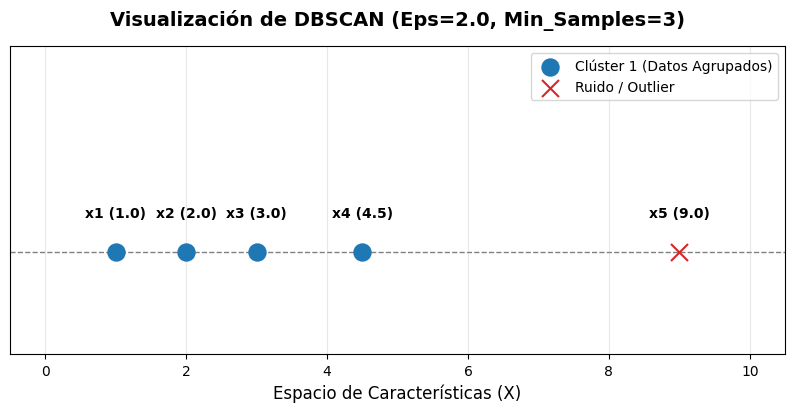

In [101]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN

# ==========================================
# PASO 1: Definir los puntos originales (1D)
# ==========================================
# Usamos exactamente los mismos 5 puntos del ejemplo numérico.
# Nota: Scikit-learn requiere que los datos tengan forma de matriz (n_muestras, n_características).
# Por eso añadimos una columna de ceros en el eje Y para poder graficarlos en un plano cartesiano plano.
X_1D = np.array([1.0, 2.0, 3.0, 4.5, 9.0])
X = np.column_stack((X_1D, np.zeros_like(X_1D)))

# ===================================================
# PASO 2: Configurar e inicializar el modelo DBSCAN
# ===================================================
# eps = 2.0 (Radio de vecindad máximo)
# min_samples = 3 (Mínimo de puntos requeridos para ser Punto Nuclear, incluyéndose a sí mismo)
dbscan = DBSCAN(eps=2.0, min_samples=3)

# ===================================================
# PASO 3: Entrenar el algoritmo con todos los datos
# ===================================================
# Recuerda que en aprendizaje no supervisado usamos el 100% de los datos para entrenar
dbscan.fit(X)

# ===================================================
# PASO 4: Extraer los resultados (Etiquetas y Núcleos)
# ===================================================
# Las etiquetas (labels_) indican a qué clúster pertenece cada punto.
# Un valor de -1 significa que el algoritmo lo identificó como RUIDO (Outlier).
etiquetas = dbscan.labels_

# core_sample_indices_ nos dice qué puntos del dataset original lograron ser Nucleares
indices_nucleares = dbscan.core_sample_indices_

# ===================================================
# PASO 5: Mostrar resultados numéricos por consola
# ===================================================
print("--- RESULTADOS DEL ANÁLISIS DBSCAN ---")
for i, (punto, etiqueta) in enumerate(zip(X_1D, etiquetas)):
    rol = "Nuclear (Core)" if i in indices_nucleares else (
        "Frontera (Border)" if etiqueta != -1 else "Ruido (Noise)"
    )
    print(
        f"Punto x{i+1} = {punto:<4} -> Estado: {rol:<18} -> Asignación: Clúster {etiqueta if etiqueta != -1 else 'Ruido'}"
    )

# ===================================================
# PASO 6: Representación Gráfica Final
# ===================================================
plt.figure(figsize=(10, 4))

# Dibujamos una línea horizontal gris para representar el espacio unidimensional
plt.axhline(0, color="gray", linestyle="--", linewidth=1, zorder=1)

# Separamos los puntos que pertenecen al Clúster 1 de los que son Ruido para darles colores diferentes
cluster_puntos = X_1D[etiquetas == 0]
ruido_puntos = X_1D[etiquetas == -1]

# Graficamos el Clúster 1 (en color verde azulado) y el Ruido (en color rojo)
plt.scatter(
    cluster_puntos,
    np.zeros_like(cluster_puntos),
    color="#1f77b4",
    s=150,
    label="Clúster 1 (Datos Agrupados)",
    zorder=2,
)
plt.scatter(
    ruido_puntos,
    np.zeros_like(ruido_puntos),
    color="#d62728",
    s=150,
    marker="x",
    label="Ruido / Outlier",
    zorder=2,
)

# Añadimos etiquetas de texto flotantes sobre cada punto para identificarlos fácilmente en el gráfico
nombres_puntos = ["x1 (1.0)", "x2 (2.0)", "x3 (3.0)", "x4 (4.5)", "x5 (9.0)"]
for i, punto in enumerate(X_1D):
    plt.annotate(
        nombres_puntos[i],
        (punto, 0.02),
        textcoords="offset points",
        xytext=(0, 10),
        ha="center",
        fontsize=10,
        fontweight="bold",
    )

# Configuración estética del gráfico
plt.title(
    "Visualización de DBSCAN (Eps=2.0, Min_Samples=3)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Espacio de Características (X)", fontsize=12)
plt.xlim(-0.5, 10.5)
plt.ylim(-0.1, 0.2)  # Elevamos un poco el límite superior para dar espacio a los textos
plt.yticks([])  # Ocultamos el eje Y ya que nuestros datos son de 1D
plt.grid(axis="x", alpha=0.3)
plt.legend(loc="upper right")

plt.show()

## Ejemplo DBSCAN (caso 2 dimensiones $(x_i, y_i)$)

* **Radio ($\epsilon$) = 2.0**
* **Mínimo de puntos ($M$) = 3**

### Nuestros Puntos en 2D:

* $x_1 = (1, 2)$
* $x_2 = (2, 2)$
* $x_3 = (2, 3.5)$
* $x_4 = (3.5, 4.5)$
* $x_5 = (7, 2)$

---

### Desarrollo Manual de DBSCAN en 2D

Inicializamos el contador de clústeres: **$C = 1$**.

#### Iteración 1: Analizamos el punto $x_1 = (1, 2)$

Calculamos la distancia Euclidiana desde $x_1$ hacia todos los demás puntos para ver cuáles entran en su radio de búsqueda ($\le 2.0$):

* $D(x_1, x_1) = 0 \le 2$ (Vecino $\checkmark$)
* $D(x_1, x_2) = \sqrt{(2-1)^2 + (2-2)^2} = \sqrt{1 + 0} = 1.0 \le 2$ (Vecino $\checkmark$)
* $D(x_1, x_3) = \sqrt{(2-1)^2 + (3.5-2)^2} = \sqrt{1 + 2.25} = \sqrt{3.25} \approx 1.80 \le 2$ (Vecino $\checkmark$)
* $D(x_1, x_4) = \sqrt{(3.5-1)^2 + (4.5-2)^2} = \sqrt{6.25 + 6.25} = \sqrt{12.5} \approx 3.54 > 2$ (No)
* $D(x_1, x_5) = \sqrt{(7-1)^2 + (2-2)^2} = \sqrt{36 + 0} = 6.0 > 2$ (No)

**Vecindario de $x_1$:** $V = \{x_1, x_2, x_3\} \rightarrow |V| = 3$.
Como cumple que $|V| \ge 3$, **$x_1$ es clasificado como Punto Nuclear**. Se crea el **Clúster 1** y se añade a $x_1$.

---

#### Paso de Expansión del Clúster 1

Revisamos los vecinos descubiertos por $x_1$ que están en la lista de espera: $\{x_2, x_3\}$.

* **Evaluamos a $x_2 = (2, 2)$:**
    * Lo unimos al Clúster 1.
    * Calculamos su vecindario (puntos a distancia $\le 2.0$ de $x_2$):
        * $D(x_2, x_1) = 1.0 \le 2$
        * $D(x_2, x_3) = \sqrt{(2-2)^2 + (3.5-2)^2} = 1.5 \le 2$
        * Los puntos $x_4$ y $x_5$ quedan fuera del radio por distancia.   
    * **Vecindario de $x_2$:** $V = \{x_1, x_2, x_3\} \rightarrow |V| = 3$.
    * Como $|V| \ge 3$, **$x_2$ también es un Punto Nuclear** y refuerza el clúster.

* **Evaluamos a $x_3 = (2, 3.5)$:**
    * Lo unimos al Clúster 1.
    * Calculamos su vecindario (puntos a distancia $\le 2.0$ de $x_3$):
        * Ya sabemos que $x_1$ (distancia 1.80) y $x_2$ (distancia 1.5) entran.
        * Miremos a $x_4 = (3.5, 4.5)$: $D(x_3, x_4) = \sqrt{(3.5-2)^2 + (4.5-3.5)^2} = \sqrt{2.25 + 1} = \sqrt{3.25} \approx 1.80 \le 2$ **(¡Entra!)**
    * **Vecindario de $x_3$:** $V = \{x_1, x_2, x_3, x_4\} \rightarrow |V| = 4$.
    * Como $|V| \ge 3$, **$x_3$ es un Punto Nuclear** muy potente. Al descubrir a un nuevo integrante ($x_4$), **lo sumamos a la cola de expansión**.

* **Evaluamos al nuevo invitado, $x_4 = (3.5, 4.5)$:**
    * Lo unimos al Clúster 1.
    * Calculamos su vecindario (puntos a distancia $\le 2.0$ de $x_4$):
    * El único punto que tiene cerca es $x_3$ (distancia 1.80). Los demás están demasiado lejos.
    * **Vecindario de $x_4$:** $V = \{x_3, x_4\} \rightarrow |V| = 2$.
    * Como $|V| = 2$ (menor que nuestro mínimo de 3), **$x_4$ NO es un punto nuclear**. Se clasifica formalmente como **Punto Frontera**.
    * Al no ser nuclear, no aporta nuevos vecinos y la expansión del Clúster 1 finaliza oficialmente aquí.

Incrementamos el contador de clústeres: **$C = 2$**.

---

#### Iteración 2: Analizamos el punto $x_5 = (7, 2)$

*(El algoritmo ignora $x_2, x_3, x_4$ porque ya pertenecen al Clúster 1).*

* Calculamos las distancias desde $x_5$ y vemos que está completamente aislado en el plano cartesiano.
* **Vecindario de $x_5$:** $V = \{x_5\} \rightarrow |V| = 1$.
* Como $|V| = 1 < 3$, no cumple ninguna condición de densidad. El algoritmo lo etiqueta como **Ruido (Noise / Outlier)** y le asigna el valor `-1`.

---

### Tabla Resumen del Caso 2D

| Punto | Coordenadas $(X, Y)$ | Vecinos Totales ($|V|$) | Rol Asignado | Clúster Asignado |
| :--- | :--- | :--- | :--- | :--- |
| **$x_1$** | $(1.0, 2.0)$ | 3 | **Nuclear (Core)** | Clúster 1 |
| **$x_2$** | $(2.0, 2.0)$ | 3 | **Nuclear (Core)** | Clúster 1 |
| **$x_3$** | $(2.0, 3.5)$ | 4 | **Nuclear (Core)** | Clúster 1 |
| **$x_4$** | $(3.5, 4.5)$ | 2 | **Frontera (Border)** | Clúster 1 |
| **$x_5$** | $(7.0, 2.0)$ | 1 | **Ruido (Noise)** | Ninguno (Etiqueta `-1`) |

Con este desglose matemático manuscrito y el script gráfico que genera los diámetros en 2D que te di hace un momento, tienes una sección de estudio absolutamente impecable y autoexplicativa. ¡Ya tienes el universo del aprendizaje no supervisado (K-means, Medoides, Espectral y DBSCAN) perfectamente dominado y estructurado!

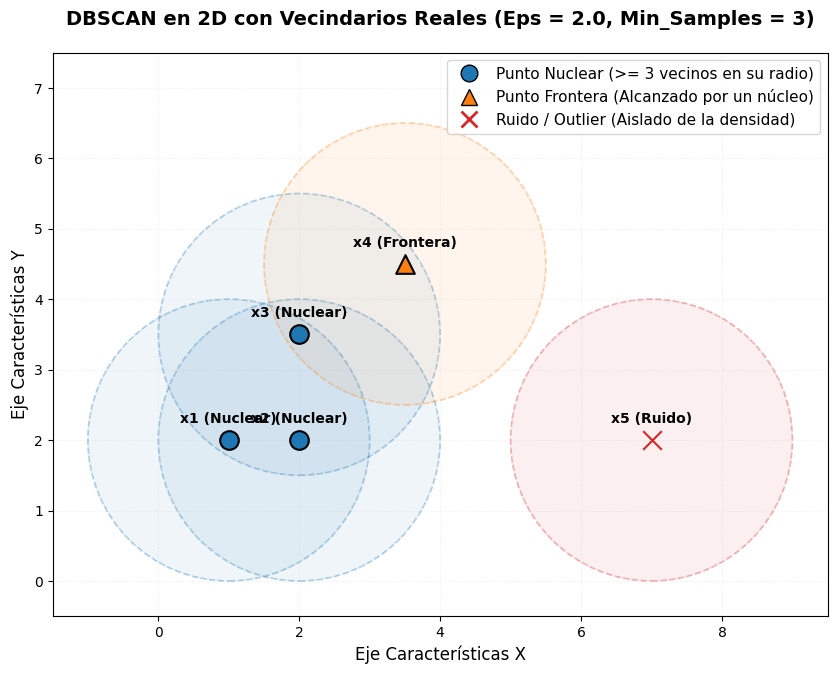

In [102]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import DBSCAN

# ==========================================
# PASO 1: Definir los puntos originales en 2D (X, Y)
# ==========================================
X = np.array([
    [1.0, 2.0],  # x1
    [2.0, 2.0],  # x2
    [2.0, 3.5],  # x3
    [3.5, 4.5],  # x4
    [7.0, 2.0],  # x5
])

# Parametros de DBSCAN
EPSILON = 2.0        # (Radio de vecindad máximo)
MIN_SAMPLES = 3      # (Mínimo de puntos requeridos para ser Punto Nuclear, incluyéndose a sí mismo)

# ==========================================
# PASO 2: Entrenar el modelo DBSCAN
# ==========================================
# Recuerda que en aprendizaje no supervisado usamos el 100% de los datos para entrenar
dbscan = DBSCAN(eps=EPSILON, min_samples=MIN_SAMPLES)
dbscan.fit(X)

# ===================================================
# PASO 3: Extraer los resultados (Etiquetas y Núcleos)
# ===================================================
# Las etiquetas (labels_) indican a qué clúster pertenece cada punto.
# Un valor de -1 significa que el algoritmo lo identificó como RUIDO (Outlier).

etiquetas = dbscan.labels_

# core_sample_indices_ nos dice qué puntos del dataset original lograron ser Nucleares
indices_nucleares = dbscan.core_sample_indices_

# ==========================================
# PASO 4: Configurar el Gráfico Avanzado en 2D
# ==========================================
fig, ax = plt.subplots(figsize=(10, 8))

# Paleta de colores para los ROLES técnicos
colores_roles = {
    "Nuclear": "#1f77b4",  # Azul
    "Frontera": "#ff7f0e",  # Naranja
    "Ruido": "#d62728",  # Rojo
}

# Iteramos sobre cada punto para clasificarlo, graficarlo y dibujarle su vecindario
for i, punto in enumerate(X):
    # 1. Determinar el rol técnico del punto
    if i in indices_nucleares:
        rol = "Nuclear"
        color = colores_roles["Nuclear"]
        marcador = "o"
    elif etiquetas[i] != -1:
        rol = "Frontera"
        color = colores_roles["Frontera"]
        marcador = "^"
    else:
        rol = "Ruido"
        color = colores_roles["Ruido"]
        marcador = "x"

    # 2. Dibujar el VECINDARIO (Círculo de radio Épsilon)
    # El diámetro visual representa el área donde el punto busca vecinos
    circulo_vecindario = plt.Circle(
        punto,
        radius=EPSILON,
        color=color,
        fill=True,
        alpha=0.07,  # Transparente para que no tape a los demás
        linestyle="--",
        linewidth=1.5,
    )
    # Añadimos la línea del borde del círculo
    circulo_borde = plt.Circle(
        punto,
        radius=EPSILON,
        color=color,
        fill=False,
        alpha=0.3,
        linestyle="--",
        linewidth=1.2,
    )
    ax.add_patch(circulo_vecindario)
    ax.add_patch(circulo_borde)

    # 3. Graficar el PUNTO real en el centro de su círculo
    ax.scatter(
        punto[0],
        punto[1],
        color=color,
        s=180,
        marker=marcador,
        edgecolors="black" if marcador != "x" else None,
        linewidths=1.5,
        zorder=3,
    )

    # 4. Colocar la etiqueta de texto del punto
    ax.text(
        punto[0],
        punto[1] + 0.25,
        f"x{i+1} ({rol})",
        ha="center",
        fontsize=10,
        fontweight="bold",
        zorder=4,
    )

# ==========================================
# PASO 5: Estética y Leyendas del Gráfico
# ==========================================
# Creamos una leyenda personalizada para los roles
leyendas = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colores_roles["Nuclear"],
        markersize=12,
        markeredgecolor="black",
        label="Punto Nuclear (>= 3 vecinos en su radio)",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="^",
        color="w",
        markerfacecolor=colores_roles["Frontera"],
        markersize=12,
        markeredgecolor="black",
        label="Punto Frontera (Alcanzado por un núcleo)",
    ),
    plt.Line2D(
        [0],
        [0],
        marker="x",
        color="w",
        markeredgecolor=colores_roles["Ruido"],
        markersize=12,
        markeredgewidth=2,
        label="Ruido / Outlier (Aislado de la densidad)",
    ),
]
ax.legend(handles=leyendas, loc="upper right", fontsize=11, frameon=True)

# Configuración de ejes ecuánimes (crucial para que los círculos no se vean como óvalos)
ax.set_aspect("equal", adjustable="box")
ax.set_xlim(-1.5, 9.5)
ax.set_ylim(-0.5, 7.5)
ax.grid(True, alpha=0.2, linestyle=":")

ax.set_title(
    f"DBSCAN en 2D con Vecindarios Reales (Eps = {EPSILON}, Min_Samples = {MIN_SAMPLES})",
    fontsize=14,
    fontweight="bold",
    pad=20,
)
ax.set_xlabel("Eje Características X", fontsize=12)
ax.set_ylabel("Eje Características Y", fontsize=12)

plt.show()

# Algoritmo Mean Shift (Desplazamiento de Media)

Encuentra los modos (picos de densidad) en los datos de forma iterativa.

1. **Definir el parámetro $h$ (Bandwidth):** Determina el radio de la ventana de búsqueda (el tamaño del círculo).
2. **Para cada punto $x_i$** del conjunto de datos (actuando como el centro actual $y_c = x_i$):
    * **2.1.** Encontrar todos los puntos del dataset que caen dentro de la distancia $h$ desde el centro actual $y_c$.
    * **2.2. Calcular el vector de desplazamiento (Mean Shift Vector):** Obtener el centro geométrico (media) de esos puntos vecinos.
    * **2.3. Actualizar la posición:** Mover el centro actual $y_c$ hacia la nueva media calculada.
    * **2.4. Comprobar convergencia:** Si el cambio de posición es menor que un umbral mínimo (cercano a 0), detenerse. Si no, volver al paso 2.1 con la nueva posición.


3. **Asignación de Clústeres:** Agrupar todos los puntos originales cuyas trayectorias terminaron en el mismo pico de densidad (modo).



## Ejemplo Numérico Manual (1D)

Vamos a hacerlo con números en una sola dimensión para ver cómo se calcula el desplazamiento.

* **Ancho de banda ($h$) = 3.0**

### Nuestros Datos:

Tenemos una zona densa a la izquierda y un punto aislado a la derecha:

* $x_1 = 1.0$
* $x_2 = 2.0$
* $x_3 = 3.0$
* $x_4 = 8.0$

### Evaluemos la trayectoria para el punto $x_3 = 3.0$

Colocamos nuestro centro inicial en su propia posición: $y_c = 3.0$.

* **Iteración 1:**
    * Buscamos qué puntos están a distancia $\le h (3.0)$ de nuestro centro $y_c = 3.0$.
    * Distancias:
        * a $x_1$: $|1 - 3| = 2 \le 3$ (Entra)
        * a $x_2$: $|2 - 3| = 1 \le 3$ (Entra)
        * a $x_3$: $|3 - 3| = 0 \le 3$ (Entra)
        * a $x_4$: $|8 - 3| = 5 > 3$ (Queda fuera)
    * Puntos dentro de la ventana: $\{1.0, 2.0, 3.0\}$.
    * **Calculamos el nuevo centro de gravedad (Media):** 
    $$\text{Nueva Media} = \frac{1.0 + 2.0 + 3.0}{3} = \frac{6.0}{3} = 2.0$$
    * **El Desplazamiento:** El centro se mueve de $3.0$ a $2.0$. Nuestra nueva posición es $y_c = 2.0$.


* **Iteración 2:**
    * Ahora buscamos qué puntos están a distancia $\le 3.0$ de nuestro nuevo centro $y_c = 2.0$.
    * Puntos dentro de la ventana: $\{1.0, 2.0, 3.0\}$ (el punto $8.0$ sigue quedando fuera).
    * **Calculamos el nuevo centro de gravedad:**
    
    $$\text{Nueva Media} = \frac{1.0 + 2.0 + 3.0}{3} = 2.0$$
    
    
    * **Convergencia:** El centro era $2.0$ y la nueva media vuelve a dar $2.0$. El movimiento es de $0$. **El punto ha convergido en la cumbre $2.0$.**



Si hicieras este mismo ejercicio con $x_1$ y $x_2$, verías que sus caminos también terminarían congelándose en la cumbre $2.0$. Por lo tanto, $\{x_1, x_2, x_3\}$ formarán el **Clúster 1**. El punto $x_4=8.0$ está tan lejos que terminará convergiendo en su propia cumbre ($8.0$), formando el **Clúster 2**.

---



Ancho de banda (h) óptimo convertido y verificado: 1.00

Número de clústeres detectados automáticamente: 2
Punto x1 = [1. 1.] -> Asignado al Clúster: 1 (Cumbre en: [1.16666667 1.16666667])
Punto x2 = [1.5 1. ] -> Asignado al Clúster: 1 (Cumbre en: [1.16666667 1.16666667])
Punto x3 = [1.  1.5] -> Asignado al Clúster: 1 (Cumbre en: [1.16666667 1.16666667])
Punto x4 = [5. 5.] -> Asignado al Clúster: 0 (Cumbre en: [5.16666667 5.16666667])
Punto x5 = [5.5 5. ] -> Asignado al Clúster: 0 (Cumbre en: [5.16666667 5.16666667])
Punto x6 = [5.  5.5] -> Asignado al Clúster: 0 (Cumbre en: [5.16666667 5.16666667])


C:\Users\willi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\cluster\_mean_shift.py:291: UserWarning: Binning data failed with provided bin_size=1.000000, using data points as seeds.
  warnings.warn(


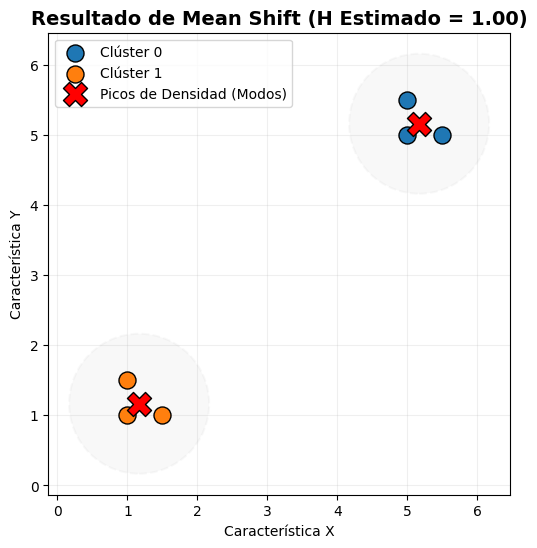

In [109]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import MeanShift, estimate_bandwidth

# ==========================================
# PASO 1: Puntos en 2D (Dos nubes de puntos)
# ==========================================
X = np.array([
    [1.0, 1.0],
    [1.5, 1.0],
    [1.0, 1.5],  # Nube densa 1
    [5.0, 5.0],
    [5.5, 5.0],
    [5.0, 5.5],  # Nube densa 2
])

# ===================================================
# PASO 2: Estimación automática del Ancho de Banda (h)
# ===================================================
# Cuantila controla qué tan grande o pequeño es el radio estimado
h_estimado = estimate_bandwidth(X, quantile=0.3)

# SOLUCIÓN: Convertimos a float de Python y aseguramos que si da 0.0, tome un valor mínimo (ej. 1.0)
if h_estimado == 0.0:
    h_estimado = 1.0  # O el valor de radio que consideres adecuado para la escala de tus datos
else:
    h_estimado = float(h_estimado)

print(f"Ancho de banda (h) óptimo convertido y verificado: {h_estimado:.2f}\n")

# ===================================================
# PASO 3: Inicializar y entrenar el modelo Mean Shift
# ===================================================
# bin_seeding=True acelera el algoritmo agrupando puntos iniciales en celdas
ms = MeanShift(bandwidth=h_estimado, bin_seeding=True)
ms.fit(X)

etiquetas = ms.labels_
centros_cluster = ms.cluster_centers_
num_clusteres = len(np.unique(etiquetas))

# ===================================================
# PASO 4: Mostrar resultados por consola
# ===================================================
print(f"Número de clústeres detectados automáticamente: {num_clusteres}")
for i, punto in enumerate(X):
    print(
        f"Punto x{i+1} = {punto} -> Asignado al Clúster: {etiquetas[i]} (Cumbre en: {centros_cluster[etiquetas[i]]})"
    )

# ===================================================
# PASO 5: Representación Gráfica Final
# ===================================================
plt.figure(figsize=(8, 6))

colores = ["#1f77b4", "#ff7f0e"]

# Graficar los puntos originales coloreados por su clúster
for k in range(num_clusteres):
    puntos_del_cluster = X[etiquetas == k]
    plt.scatter(
        puntos_del_cluster[:, 0],
        puntos_del_cluster[:, 1],
        color=colores[k],
        s=150,
        label=f"Clúster {k}",
        edgecolors="black",
        zorder=2,
    )

# Graficar las CUMBRES (Centros a los que llegaron los puntos)
plt.scatter(
    centros_cluster[:, 0],
    centros_cluster[:, 1],
    color="red",
    marker="X",
    s=300,
    edgecolors="black",
    label="Picos de Densidad (Modos)",
    zorder=3,
)

# Dibujar de forma ilustrativa el radio de influencia (h) alrededor de las cumbres
for centro in centros_cluster:
    circulo_h = plt.Circle(
        centro,
        radius=h_estimado,
        color="gray",
        fill=True,
        alpha=0.05,
        linestyle="--",
        linewidth=1.5,
    )
    plt.gca().add_patch(circulo_h)

# Ajustes estéticos
plt.title(
    f"Resultado de Mean Shift (H Estimado = {h_estimado:.2f})",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Característica X")
plt.ylabel("Característica Y")
plt.grid(True, alpha=0.2)
plt.legend(loc="upper left")
plt.gca().set_aspect("equal", adjustable="box")

plt.show()

### 7. Algoritmo EM (Esperanza-Maximización)
Proceso iterativo para estimar parámetros en modelos probabilísticos con variables latentes.
1.  **Inicializar el modelo** con parámetros aleatorios (medias, covarianzas y pesos de mezcla).
2.  Repetir hasta convergencia de la verosimilitud:
    *   2.1. **Paso E (Expectation)**: estimar la probabilidad de que cada ejemplo pertenezca a cada componente basándose en los parámetros actuales.
    *   2.2. **Paso M (Maximization)**: recalcular los parámetros del modelo (estimadores de máxima verosimilitud) utilizando las asignaciones probabilísticas obtenidas en el paso E.

<>:92: SyntaxWarning: invalid escape sequence '\m'
<>:92: SyntaxWarning: invalid escape sequence '\m'
C:\Users\willi\AppData\Local\Temp\ipykernel_6800\2913317347.py:92: SyntaxWarning: invalid escape sequence '\m'
  label="Medias Calculadas ($\mu$)",


--- RESULTADOS DEL ALGORITMO EM (GMM) ---
Punto x1 = [1. 2.] -> Prob Clúster 0: 100.00% | Prob Clúster 1: 0.00% -> Asignado a: Clúster 0
Punto x2 = [1.5 1.8] -> Prob Clúster 0: 100.00% | Prob Clúster 1: 0.00% -> Asignado a: Clúster 0
Punto x3 = [1.2 2.2] -> Prob Clúster 0: 100.00% | Prob Clúster 1: 0.00% -> Asignado a: Clúster 0
Punto x4 = [6. 5.] -> Prob Clúster 0: 0.00% | Prob Clúster 1: 100.00% -> Asignado a: Clúster 1
Punto x5 = [6.5 5.5] -> Prob Clúster 0: 0.00% | Prob Clúster 1: 100.00% -> Asignado a: Clúster 1
Punto x6 = [7.  4.8] -> Prob Clúster 0: 0.00% | Prob Clúster 1: 100.00% -> Asignado a: Clúster 1


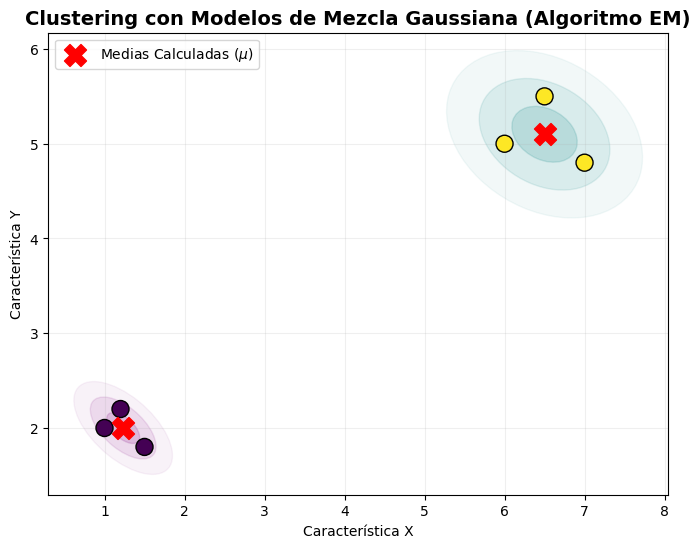

In [114]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Ellipse
from sklearn.mixture import GaussianMixture


# Función auxiliar para dibujar las elipses de covarianza (forma del clúster)
def dibujar_elipse(pos, cov, ax=None, **kwargs):
    ax = ax or plt.gca()
    if cov.ndim == 2:
        U, s, Vt = np.linalg.svd(cov)
        angulo = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        ancho, alto = 2 * np.sqrt(s)
    else:
        angulo = 0
        ancho, alto = 2 * np.sqrt(cov)
    for nsig in range(1, 4):
        ax.add_patch(
            Ellipse(
                pos,
                nsig * ancho,
                nsig * alto,
                angle=angulo,
                alpha=0.05 * (4 - nsig),
                **kwargs,
            )
        )


# ==========================================
# PASO 1: Definir los puntos originales en 2D
# ==========================================
# Creamos dos grupos de datos visuales
X = np.array([
    [1.0, 2.0],
    [1.5, 1.8],
    [1.2, 2.2],  # Grupo A (Denso)
    [6.0, 5.0],
    [6.5, 5.5],
    [7.0, 4.8],  # Grupo B (Más disperso)
])

# ===================================================
# PASO 2: Inicializar y entrenar el modelo GMM (EM)
# ===================================================
# Buscamos n_components=2 clústeres
gmm = GaussianMixture(n_components=2, covariance_type="full", random_state=42)
gmm.fit(X)

# ===================================================
# PASO 3: Extraer Parámetros Optimizados en el Paso M
# ===================================================
medias = gmm.means_
covarianzas = gmm.covariances_
etiquetas = gmm.predict(X)

# Extraer las "Responsabilidades" (Paso E): Probabilidades suavizadas
probabilidades = gmm.predict_proba(X)

# ===================================================
# PASO 4: Mostrar los resultados probabilísticos
# ===================================================
print("--- RESULTADOS DEL ALGORITMO EM (GMM) ---")
for i, punto in enumerate(X):
    print(
        f"Punto x{i+1} = {punto} -> Prob Clúster 0: {probabilidades[i,0]:.2%} | Prob Clúster 1: {probabilidades[i,1]:.2%} -> Asignado a: Clúster {etiquetas[i]}"
    )

# ===================================================
# PASO 5: Representación Gráfica Final
# ===================================================
plt.figure(figsize=(8, 6))

# Graficar los puntos originales. El color refleja su clúster principal
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=etiquetas,
    cmap="viridis",
    s=150,
    edgecolors="black",
    zorder=3,
)

# Graficar los centros (medias) calculados por el algoritmo
plt.scatter(
    medias[:, 0],
    medias[:, 1],
    color="red",
    marker="X",
    s=250,
    label="Medias Calculadas ($\mu$)",
    zorder=4,
)

# Dibujar las formas elípticas de los clústeres basadas en la covarianza
for i, (pos, cov) in enumerate(zip(medias, covarianzas)):
    dibujar_elipse(pos, cov, color="purple" if i == 0 else "teal")

plt.title(
    "Clustering con Modelos de Mezcla Gaussiana (Algoritmo EM)",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Característica X")
plt.ylabel("Característica Y")
plt.grid(True, alpha=0.2)
plt.legend(loc="upper left")
plt.show()

TypeError: BaseMixture.predict() missing 1 required positional argument: 'X'


### 6. Algoritmo de Desplazamiento de Media (Mean Shift)
Busca las modas o máximos locales de la función de densidad de los datos.
1.  **Repetir hasta convergencia**: para cada ejemplo $x_i$, actualizar su posición sustituyéndolo por el **punto medio ponderado de sus vecinos** ($x_i \leftarrow m(x_i)$) según una función núcleo (kernel).
2.  **Identificar las modas**: localizar los puntos hacia los cuales han convergido los ejemplos originales.
3.  **Asignar clústeres**: todos los ejemplos que han convergido a la misma moda pertenecen al mismo grupo.




### 7. Algoritmo EM (Esperanza-Maximización)
Proceso iterativo para estimar parámetros en modelos probabilísticos con variables latentes.
1.  **Inicializar el modelo** con parámetros aleatorios (medias, covarianzas y pesos de mezcla).
2.  Repetir hasta convergencia de la verosimilitud:
    *   2.1. **Paso E (Expectation)**: estimar la probabilidad de que cada ejemplo pertenezca a cada componente basándose en los parámetros actuales.
    *   2.2. **Paso M (Maximization)**: recalcular los parámetros del modelo (estimadores de máxima verosimilitud) utilizando las asignaciones probabilísticas obtenidas en el paso E.

### 8. Algoritmo Apriori (Reglas de Asociación)
Se basa en la intuición de que un conjunto es frecuente solo si todos sus subconjuntos lo son.
1.  Generar $L_1$ como el conjunto de todos los **1-ítems frecuentes** que superan el umbral de soporte $\epsilon$.
2.  Para $k = 2, 3, \dots$:
    *   2.1. **Generar candidatos $C_k$** combinando los ítems frecuentes de la iteración anterior ($L_{k-1}$).
    *   2.2. **Contar las apariciones** de cada candidato en el conjunto de transacciones.
    *   2.3. **Filtrar los fuertes**: mantener en $L_k$ solo aquellos candidatos cuyo soporte sea mayor o igual a $\epsilon$.
    *   2.4. Parar si no se encuentran nuevos ítems frecuentes ($L_k = \emptyset$).

### 9. Algoritmo de Propagación de Etiquetas (Semisupervisado)
Utiliza la estructura del grafo para difundir etiquetas de datos conocidos a los desconocidos.
1.  **Crear una matriz de distancia $D$** entre todos los puntos (etiquetados y no etiquetados).
2.  Obtener la **matriz de transición $T$** normalizando las distancias.
3.  **Inicializar la matriz de etiquetas $W$**: fijar las etiquetas conocidas ($W_L$) y asignar valores aleatorios a las desconocidas ($W_U$).
4.  **Repetir el proceso de difusión** ($W \leftarrow TW$) manteniendo siempre fijas las etiquetas originales de $W_L$ hasta que la matriz $W$ converja.

### 10. Procedimiento de PCA (Análisis de Componentes Principales)
1.  **Calcular la matriz de covarianzas $\Sigma$** de los datos (previamente estandarizados).
2.  **Descomponer la matriz $\Sigma$** para obtener sus valores y vectores propios.
3.  **Seleccionar los $q$ vectores propios principales**, que son aquellos asociados a los valores propios más altos, para formar las nuevas componentes ortogonales.

### 11. Técnica de Macnaughton-Smith (Jerárquico Divisivo)
1.  Seleccionar el ejemplo que, en promedio, esté **más lejano del resto** de su clúster para iniciar un nuevo grupo secundario.
2.  Mover iterativamente los casos del grupo original al nuevo grupo si su **distancia media al grupo de destino es menor** que al grupo de origen.
3.  Parar cuando no haya más elementos que cumplan el criterio de mejora de la cohesión.